In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zipfile import ZipFile
from scipy.spatial.distance import pdist
import io


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from zipfile import ZipFile
import io


def read_series(path):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    text = text.replace(";", ",")
    values = pd.read_csv(io.StringIO(text), sep=",", header=None).values
    values = np.asarray(values, dtype=float)

    if values.ndim > 1:
        if values.shape[0] == 1 or values.shape[1] == 1:
            values = values.ravel()
        else:
            values = values[:, 0]

    values = values[np.isfinite(values)]
    return values


def extract_timesets():
    archive_path = next(Path(".").glob("**/TimeSets.zip"), None)

    if archive_path is None:
        return

    with ZipFile(archive_path) as z:
        z.extractall("data/TimeSets")


timesets_path = Path("data/TimeSets")

if not timesets_path.exists():
    extract_timesets()

if not timesets_path.exists():
    raise FileNotFoundError("Положи TimeSets в data/TimeSets или TimeSets.zip в корень проекта/data")

series = {
    "S2": read_series(timesets_path / "S2.txt"),
    "S6": read_series(timesets_path / "S6.txt"),
    "Lorenz1": read_series(timesets_path / "Lorenz1.txt"),
}

for name, values in series.items():
    print(f"{name}: длина = {len(values)}, min = {values.min():.4f}, max = {values.max():.4f}")


S2: длина = 100000, min = -3.4640, max = 3.9484
S6: длина = 100000, min = 0.0951, max = 0.9750
Lorenz1: длина = 100000, min = -20.5120, max = 21.1330


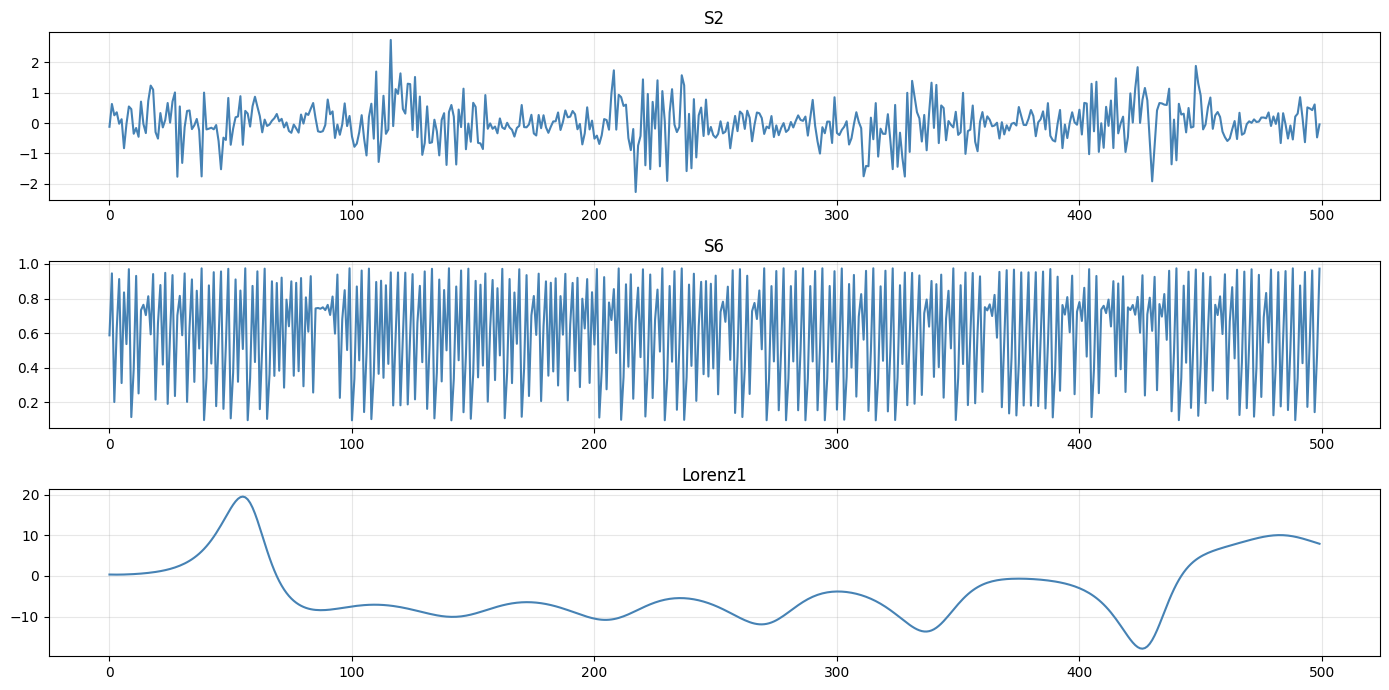

In [3]:
plt.figure(figsize=(14, 7))

for i, (name, values) in enumerate(series.items(), start=1):
    plt.subplot(3, 1, i)
    plt.plot(values[:500], color="steelblue")
    plt.title(name)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
def choose_tau(x, max_lag=200):
    x = (x - np.mean(x)) / np.std(x)

    for lag in range(1, max_lag + 1):
        corr = np.corrcoef(x[:-lag], x[lag:])[0, 1]

        if corr < 1 / np.e:
            return lag

    return 1


def embedding(x, dim, tau=1):
    n = len(x) - (dim - 1) * tau
    return np.column_stack([x[i * tau:i * tau + n] for i in range(dim)])


def corrintfast(data, d, emin, emax, n, tau=1):
    emb = embedding(data, d, tau)

    if len(emb) > 2000:
        step = int(np.ceil(len(emb) / 2000))
        emb = emb[::step]

    distances = pdist(emb)
    radii = np.logspace(np.log10(emin), np.log10(emax), n)
    corr = np.array([(distances < r).mean() for r in radii])

    return np.vstack([radii, corr])


def corr_dimension(values, max_dim=10, tau=1):
    values = (values - np.mean(values)) / np.std(values)
    emin = 0.02
    emax = 2.0
    dims = np.arange(1, max_dim + 1)
    dimensions = []

    for dim in dims:
        f = corrintfast(values, dim, emin, emax, 40, tau=tau)
        r = f[0]
        c = f[1]

        mask = (c > 0.01) & (c < 0.5)
        if mask.sum() < 3:
            mask = slice(8, 28)

        k, b = np.polyfit(np.log(r[mask]), np.log(c[mask]), 1)
        dimensions.append(k)

    return dims, np.array(dimensions)


In [5]:
max_dim = 10
corr_results = {}
taus = {}

for name, values in series.items():
    values = values[:5000]
    tau = choose_tau(values)
    taus[name] = tau
    dims, dimensions = corr_dimension(values, max_dim=max_dim, tau=tau)
    corr_results[name] = dimensions

    diffs = np.abs(np.diff(dimensions))
    stable = np.where(diffs < 0.1)[0]
    min_dim = stable[0] + 2 if len(stable) else max_dim

    print(f"{name}: tau = {tau}, минимальная размерность вложения = {min_dim}")
    print(np.round(dimensions, 3))


S2: tau = 1, минимальная размерность вложения = 10
[0.984 1.76  2.277 2.649 2.962 3.136 3.445 3.624 3.806 4.221]
S6: tau = 1, минимальная размерность вложения = 2
[0.828 0.884 0.928 0.966 1.006 1.069 1.156 1.236 1.354 1.545]
Lorenz1: tau = 31, минимальная размерность вложения = 4
[0.967 1.314 1.443 1.508 1.593 1.635 1.679 1.73  1.745 1.775]


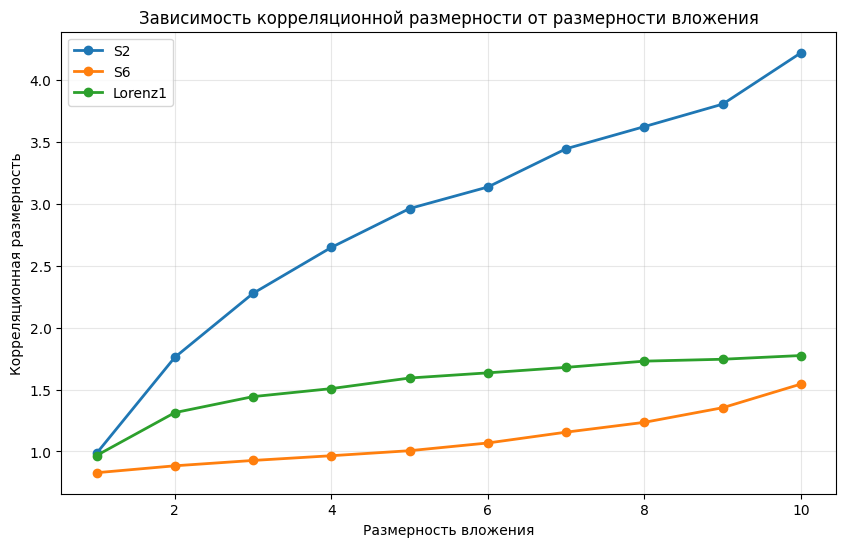

In [6]:
plt.figure(figsize=(10, 6))

for name, dimensions in corr_results.items():
    plt.plot(dims, dimensions, marker="o", linewidth=2, label=name)

plt.xlabel("Размерность вложения")
plt.ylabel("Корреляционная размерность")
plt.title("Зависимость корреляционной размерности от размерности вложения")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


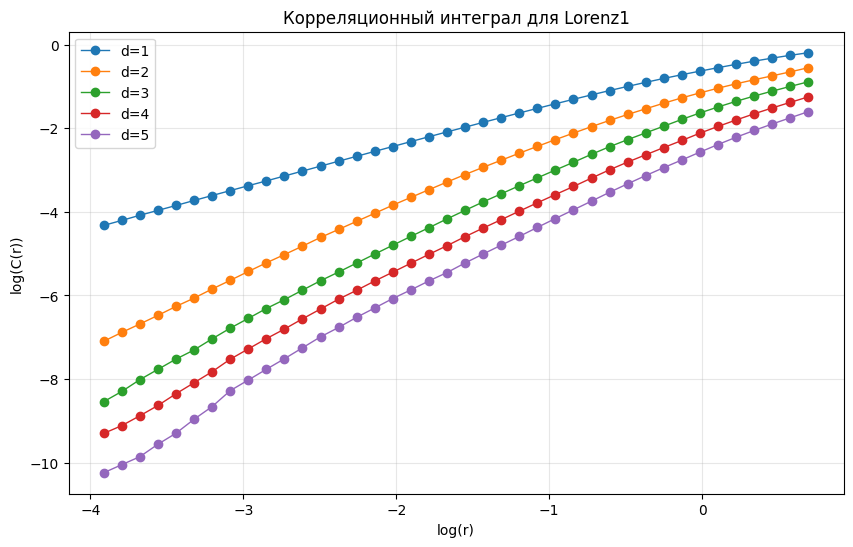

In [7]:
name = "Lorenz1"
values = (series[name][:5000] - np.mean(series[name][:5000])) / np.std(series[name][:5000])

plt.figure(figsize=(10, 6))

for dim in [1, 2, 3, 4, 5]:
    f = corrintfast(values, dim, 0.02, 2.0, 40, tau=taus[name])
    plt.plot(np.log(f[0]), np.log(f[1]), marker="o", linewidth=1, label=f"d={dim}")

plt.xlabel("log(r)")
plt.ylabel("log(C(r))")
plt.title("Корреляционный интеграл для Lorenz1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Выводы

Размерность вложения выбираем по насыщению корреляционной размерности.
Если при увеличении размерности вложения корреляционная размерность почти перестает расти, значит пространство уже достаточно большое для реконструкции аттрактора.

На реальных данных:

S2: tau = 1, насыщение не выражено, минимальная размерность по выбранному правилу = 10. Это ожидаемо для модулированного шума.

S6: tau = 1, минимальная размерность = 2.

Lorenz1: tau = 31, минимальная размерность = 4. Корреляционная размерность растет медленнее после нескольких размерностей вложения, что соответствует низкоразмерному хаотическому аттрактору.
